In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("Dataset.csv")

In [5]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [17]:
df.shape


(3900, 18)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [11]:
df.describe()


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [13]:
df.isnull().sum()


Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [15]:
df.nunique()

Customer ID               3900
Age                         53
Gender                       2
Item Purchased              25
Category                     4
Purchase Amount (USD)       81
Location                    50
Size                         4
Color                       25
Season                       4
Review Rating               26
Subscription Status          2
Shipping Type                6
Discount Applied             2
Promo Code Used              2
Previous Purchases          50
Payment Method               6
Frequency of Purchases       7
dtype: int64

In [20]:
df['Review Rating'].fillna(
    df['Review Rating'].median(),
    inplace=True
)

C:\Users\singh\AppData\Local\Temp\ipykernel_9420\285698000.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Review Rating'].fillna(


The objective is to identify high-value customers, analyze discount dependency, understand purchasing behavior, and develop data-driven retention strategies using transactional and behavioral customer data.


In [22]:
df.duplicated().sum()

0

In [24]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)

In [26]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [28]:
df.rename(columns={
    'purchase_amount_usd':'purchase_amount'
}, inplace=True)

In [34]:
df['review_rating'] = df['review_rating'].fillna(
    df['review_rating'].median()
)

In [36]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount           0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

## EDA

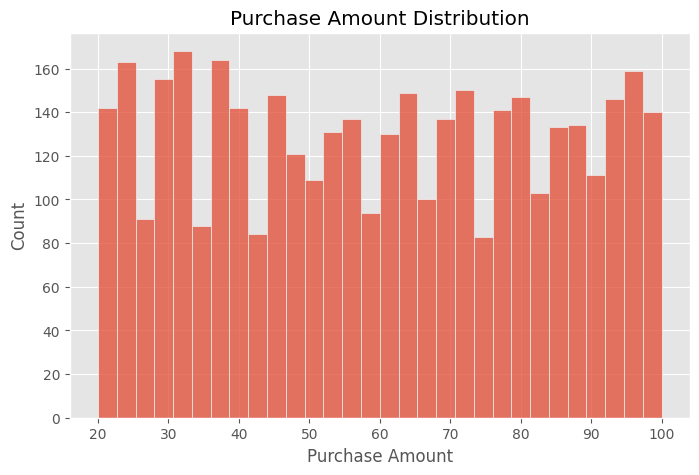

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df['purchase_amount'], bins=30)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Count")

plt.show()

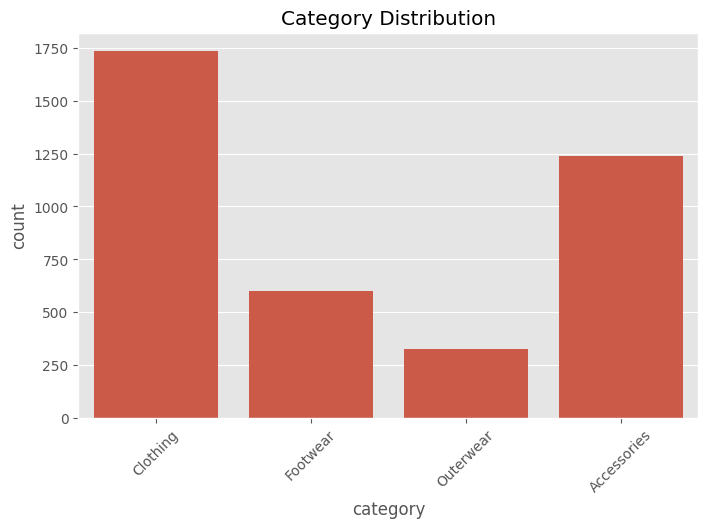

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='category')

plt.title("Category Distribution")
plt.xticks(rotation=45)

plt.show()

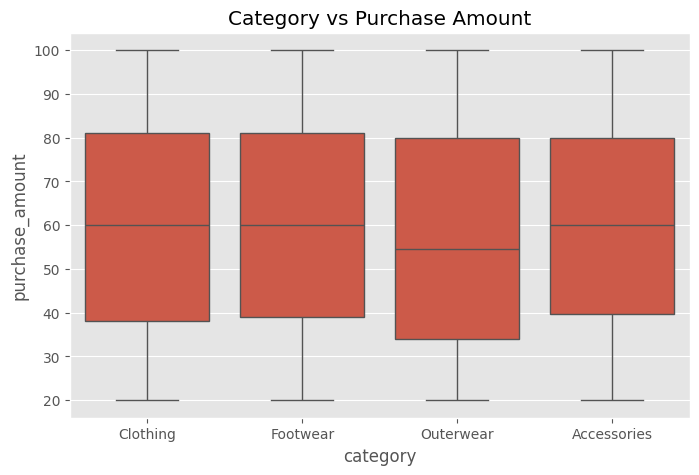

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='category',
    y='purchase_amount'
)

plt.title("Category vs Purchase Amount")

plt.show()

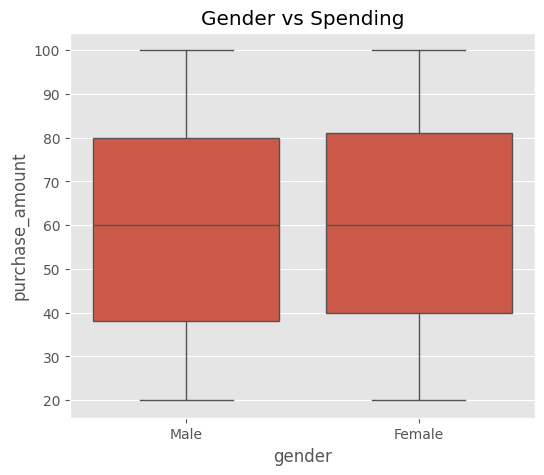

In [45]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x='gender',
    y='purchase_amount'
)

plt.title("Gender vs Spending")

plt.show()

In [47]:
df.groupby('subscription_status')['purchase_amount'].mean()

subscription_status
No     59.865121
Yes    59.491928
Name: purchase_amount, dtype: float64

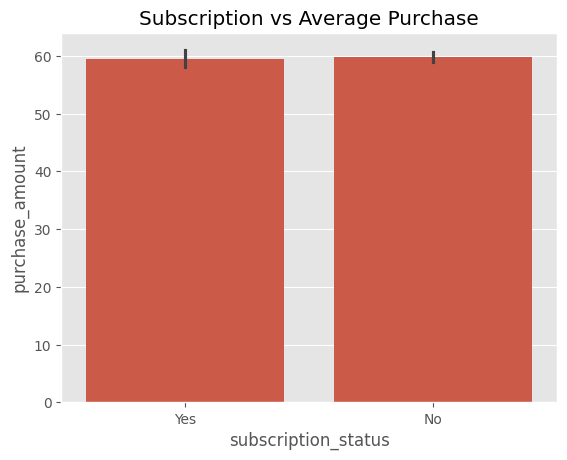

In [49]:
sns.barplot(
    data=df,
    x='subscription_status',
    y='purchase_amount'
)

plt.title("Subscription vs Average Purchase")

plt.show()

In [51]:
df.groupby('discount_applied')['purchase_amount'].mean()

discount_applied
No     60.130454
Yes    59.279070
Name: purchase_amount, dtype: float64

In [53]:
df.groupby('discount_applied')['previous_purchases'].mean()

discount_applied
No     25.056230
Yes    25.742993
Name: previous_purchases, dtype: float64

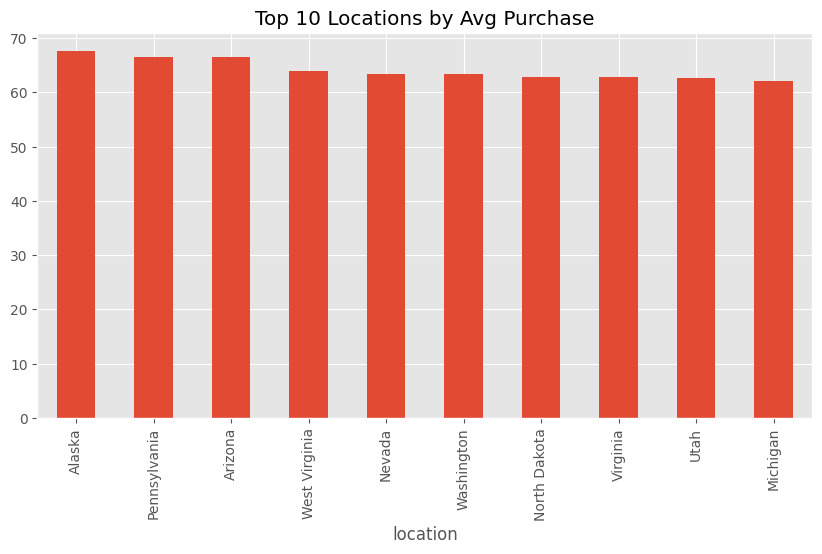

In [55]:
top_locations = (
    df.groupby('location')['purchase_amount']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_locations.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Locations by Avg Purchase")

plt.show()

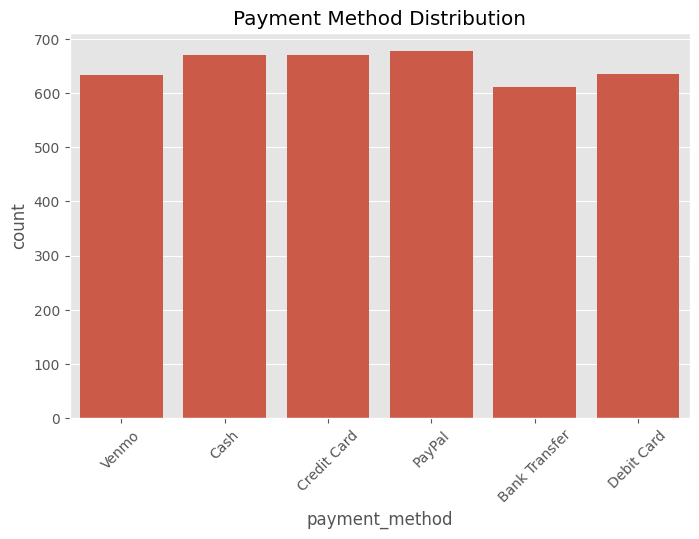

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='payment_method'
)

plt.xticks(rotation=45)

plt.title("Payment Method Distribution")

plt.show()

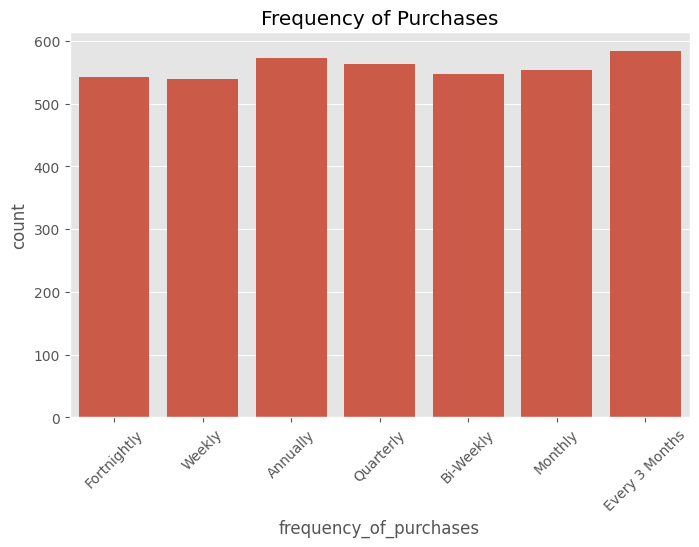

In [59]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='frequency_of_purchases'
)

plt.xticks(rotation=45)

plt.title("Frequency of Purchases")

plt.show()

# Exploratory Data Analysis (EDA) Summary & Business Insights

## 1. Purchase Amount Distribution

The purchase amount distribution shows that customer spending is relatively uniform across the range of 20–100 USD, with no major outliers or extreme premium buyers. Most transactions fall within the mid-range spending segment, indicating a stable and balanced customer base.

### Business Insight:
The brand appears to cater primarily to mid-range consumers rather than relying heavily on luxury or high-ticket customers. This reduces dependency on a small group of high spenders and creates a more stable revenue structure.

### Strategic Implications:
- The pricing strategy appears balanced and accessible.
- Revenue risk from losing a few premium customers is relatively low.
- The business can focus on improving purchase frequency and retention rather than only increasing pricing.

---

## 2. Category Distribution

Among all product categories, Clothing dominates customer purchases, followed by Accessories. Footwear contributes moderately, while Outerwear has the lowest transaction volume.

### Business Insight:
Clothing functions as the primary acquisition category for the brand, attracting the majority of customer interactions and purchases.

### Strategic Implications:
- Clothing products can be used in customer acquisition campaigns.
- Accessories can support cross-selling and upselling strategies.
- Outerwear may require seasonal campaigns or targeted marketing efforts to improve performance.

---

## 3. Category vs Purchase Amount

The boxplot analysis shows that purchase amounts across categories are relatively similar, with Accessories and Footwear having slightly higher median purchase values. Outerwear displays comparatively higher variability in customer spending.

### Business Insight:
Revenue differences across categories are driven more by purchase volume rather than large pricing differences between categories.

### Strategic Implications:
- Increasing conversion rates may be more effective than increasing prices.
- Bundle offers and accessory recommendations may help improve Average Order Value (AOV).
- Outerwear products may benefit from premium positioning or seasonal demand forecasting.

---

## 4. Gender vs Spending

Customer spending behavior is nearly identical across male and female customers, with both groups showing similar medians and spending distributions.

### Business Insight:
Gender does not appear to be a strong driver of customer spending behavior.

### Strategic Implications:
- Gender-focused promotions may not significantly impact revenue growth.
- Behavioral segmentation is likely to be more valuable than demographic segmentation.
- Marketing strategies should focus more on purchase habits, loyalty, and engagement patterns.

---

## 5. Subscription Analysis

The average purchase amount for subscribed and non-subscribed customers is nearly identical, indicating minimal monetary differentiation between the two groups.

| Subscription Status | Average Purchase Amount |
|---------------------|-------------------------|
| Yes                 | ~59.49 USD              |
| No                  | ~59.86 USD              |

### Business Insight:
The current subscription program does not significantly increase customer spending or engagement.

### Possible Reasons:
- Subscription benefits may not be compelling enough.
- Lack of personalization or exclusive incentives.
- Customers may subscribe without increasing purchase activity.

### Strategic Implications:
The subscription model should be redesigned to create stronger customer value.

### Recommendations:
- Introduce loyalty rewards and exclusive offers.
- Provide faster or premium shipping benefits.
- Add personalized recommendations and early-access campaigns.
- Build stronger emotional and convenience-based incentives.

---

## 6. Discount Dependency Analysis

Customers using discounts do not spend significantly more per transaction compared to customers not using discounts. However, discount users show slightly higher previous purchase counts.

| Discount Applied | Avg Purchase Amount | Avg Previous Purchases |
|------------------|--------------------|------------------------|
| Yes              | ~59.28 USD         | ~25.74                 |
| No               | ~60.13 USD         | ~25.05                 |

### Business Insight:
Discounts may help increase repeat engagement, but they do not significantly improve transaction value.

### Strategic Interpretation:
The business may be building “promotion-conditioned loyalty,” where customers return primarily because of discounts rather than strong brand attachment.

### Strategic Risks:
- Over-reliance on discounts can reduce profit margins.
- Customers may become less likely to purchase without promotions.
- Long-term brand loyalty may weaken.

### Recommendations:
Instead of broad discount campaigns, the company should:
- implement targeted retention offers,
- introduce personalized loyalty rewards,
- create category-specific incentives,
- focus on value-driven retention strategies rather than constant promotions.

This insight directly addresses the central business problem of the case study.

---

## 7. Location Analysis

Certain locations such as Alaska, Pennsylvania, and Arizona show relatively higher average purchase values compared to other regions.

### Business Insight:
Some geographic regions demonstrate stronger monetization potential and customer purchasing power.

### Strategic Implications:
- High-performing regions can be prioritized for premium marketing campaigns.
- Localized inventory and promotions may improve regional performance.
- Geographic targeting can help optimize marketing efficiency and ROI.

---

## 8. Payment Method Analysis

Payment method usage is relatively balanced across all available methods, including PayPal, Credit Card, Debit Card, Venmo, Cash, and Bank Transfer.

### Business Insight:
No single payment method dominates customer behavior, indicating that customers prefer diverse transaction options.

### Strategic Implications:
- Maintaining multiple payment options is important for customer convenience.
- The business has successfully created payment flexibility.
- Future optimization can focus on improving transaction experience rather than changing payment strategy.

---

## 9. Frequency of Purchases Analysis

Purchase frequency categories are relatively evenly distributed, though “Every 3 Months” and “Annually” appear slightly more common.

### Business Insight:
Customer purchasing behavior appears cyclical rather than extremely frequent, suggesting that purchases may align with seasonal buying patterns or periodic wardrobe refresh cycles.

### Strategic Implications:
- Retention campaigns should be timed around likely repurchase windows.
- Seasonal engagement strategies may improve repeat purchases.
- Predictive replenishment and reminder campaigns could strengthen retention.

---

# Overall EDA Conclusion

The analysis suggests that the brand operates with a stable mid-range customer base and balanced purchasing behavior across demographics and payment methods. However, customer retention appears partially dependent on promotional activity rather than strong organic loyalty.

While the business demonstrates healthy repeat engagement, the current subscription and discount strategies are not significantly improving customer spending behavior. This indicates an opportunity to shift from promotion-driven retention toward personalized loyalty-building strategies.

The next stage of analysis will focus on feature engineering and customer segmentation to identify:
- high-value customers,
- loyalty tiers,
- annual customer value,
- discount dependency patterns,
- and retention-focused customer groups.

These engineered features will support deeper SQL analysis and dashboard development in the later stages of the project.

In [62]:
df['subscription_flag'] = df['subscription_status'].map({
    'Yes':1,
    'No':0
})

In [64]:
df['discount_flag'] = df['discount_applied'].map({
    'Yes':1,
    'No':0
})

In [66]:
df['promo_flag'] = df['promo_code_used'].map({
    'Yes':1,
    'No':0
})

In [68]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['purchase_scaled',
    'previous_scaled']] = scaler.fit_transform(
    df[['purchase_amount', 'previous_purchases']]
)

In [86]:
df['loyalty_score'] = (
    0.45 * df['previous_scaled'] +
    0.35 * df['purchase_scaled'] +
    0.15 * df['subscription_flag'] +
    0.05 * (1 - df['discount_flag'])
) * 100

In [88]:
df['customer_tier'] = pd.qcut(
    df['loyalty_score'],
    q=4,
    labels=['Bronze', 'Silver', 'Gold', 'Platinum']
)

In [90]:
df['satisfaction_flag'] = np.where(
    df['review_rating'] >= 4,
    'Satisfied',
    'Unsatisfied'
)

In [92]:
freq_map = {
    'Weekly':52,
    'Fortnightly':26,
    'Monthly':12,
    'Quarterly':4,
    'Annually':1,
    'Bi-Weekly':24,
    'Every 3 Months':4
}

df['purchase_frequency_num'] = (
    df['frequency_of_purchases']
    .map(freq_map)
)

In [94]:
df['estimated_annual_value'] = (
    df['purchase_amount'] *
    df['purchase_frequency_num']
)

In [96]:
threshold = df['purchase_amount'].quantile(0.75)

df['high_value_customer'] = np.where(
    df['purchase_amount'] >= threshold,
    1,
    0
)

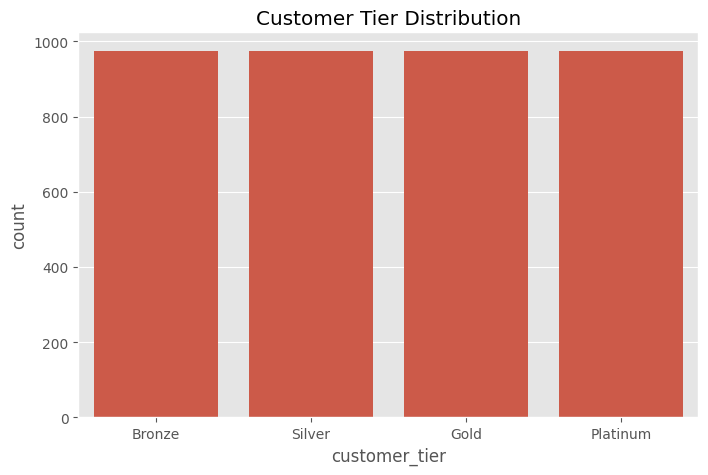

In [98]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='customer_tier'
)

plt.title("Customer Tier Distribution")

plt.show()

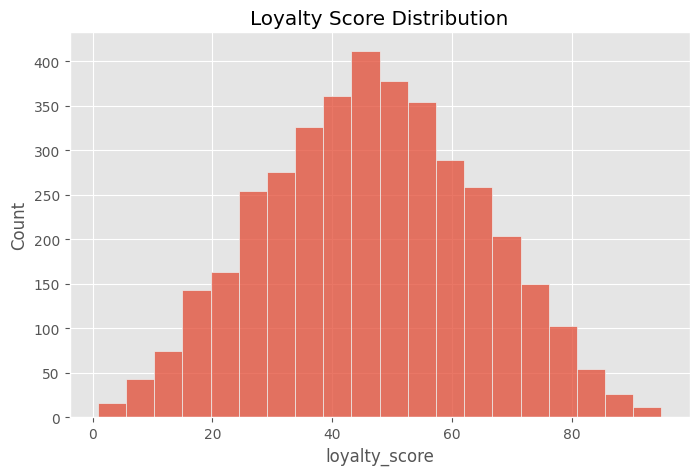

In [100]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['loyalty_score'],
    bins=20
)

plt.title("Loyalty Score Distribution")

plt.show()

# Feature Engineering

## Introduction

To move beyond basic descriptive analysis and build meaningful customer intelligence, feature engineering techniques were applied to transform raw transactional and behavioral data into actionable business metrics.

The objective of this phase was to:
- quantify customer loyalty,
- estimate long-term customer value,
- identify high-value customers,
- and create structured customer segments that can support retention strategy development.

The engineered features were specifically designed to align with the business goals outlined in the case study, particularly around customer retention, loyalty evaluation, and promotion dependency analysis.

---

# 1. Subscription Flag

A binary subscription indicator was created to numerically represent whether a customer is subscribed to the platform.

| Subscription Status | Encoded Value |
|---------------------|---------------|
| Yes                 | 1 |
| No                  | 0 |

### Purpose:
This feature allows subscription behavior to contribute directly to loyalty analysis and customer scoring models.

### Business Importance:
Subscribed customers are generally expected to show:
- stronger platform commitment,
- higher retention potential,
- and deeper brand engagement.

---

# 2. Discount Dependency Flag

A binary feature was created to represent whether a customer used discounts during purchases.

| Discount Applied | Encoded Value |
|------------------|---------------|
| Yes              | 1 |
| No               | 0 |

### Purpose:
This feature helps identify customers whose engagement may be highly dependent on promotional incentives.

### Business Importance:
Understanding discount dependency is critical for:
- evaluating promotion effectiveness,
- identifying margin risks,
- and distinguishing genuine loyalty from promotion-driven behavior.

---

# 3. Promotional Usage Flag

A separate binary feature was engineered to capture promo code usage behavior.

| Promo Code Used | Encoded Value |
|-----------------|---------------|
| Yes             | 1 |
| No              | 0 |

### Purpose:
This feature helps analyze customer responsiveness to marketing campaigns and promotional activity.

### Business Importance:
Promo code behavior can indicate:
- campaign sensitivity,
- price-conscious purchasing behavior,
- and marketing engagement patterns.

---

# 4. Feature Normalization

Numerical variables such as:
- Purchase Amount
- Previous Purchases

were normalized using Min-Max Scaling.

### Reason for Normalization:
These variables operate on different numerical scales. Without normalization, larger-scale variables could dominate the loyalty scoring system unfairly.

### Strategic Importance:
Normalization ensures balanced contribution from all important behavioral features during loyalty score generation.

---

# 5. Loyalty Score Engineering

A custom loyalty scoring framework was developed to estimate overall customer loyalty and long-term retention potential.

The final loyalty score was calculated using weighted behavioral indicators:

| Feature | Weight |
|----------|--------|
| Previous Purchases | 45% |
| Purchase Amount | 35% |
| Subscription Status | 15% |
| Low Discount Dependency | 5% |

### Loyalty Score Formula:
The scoring framework rewards customers who:
- purchase frequently,
- spend more,
- subscribe to the platform,
- and rely less on discounts.

### Business Rationale:
Repeat purchasing behavior was assigned the highest importance because it represents the strongest indicator of long-term engagement and customer retention.

Purchase amount was weighted heavily to account for revenue contribution, while subscription status and discount independence contributed smaller but meaningful loyalty signals.

### Strategic Importance:
The loyalty score creates a measurable customer value framework that can support:
- customer prioritization,
- retention campaigns,
- loyalty program design,
- and personalized marketing strategies.

---

# 6. Customer Tier Segmentation

Customers were segmented into four loyalty tiers using quartile-based segmentation on the loyalty score distribution.

| Tier | Description |
|------|-------------|
| Bronze | Lowest loyalty quartile |
| Silver | Moderate-low loyalty |
| Gold | Moderate-high loyalty |
| Platinum | Highest loyalty quartile |

### Reason for Quartile-Based Segmentation:
Quartile segmentation ensures:
- balanced customer groups,
- unbiased classification,
- and data-driven customer categorization.

### Business Importance:
Customer tiers simplify strategic decision-making by allowing the business to:
- identify premium customers,
- prioritize retention efforts,
- personalize marketing campaigns,
- and optimize loyalty initiatives.

### Strategic Applications:
- Bronze → re-engagement campaigns
- Silver → upselling opportunities
- Gold → retention optimization
- Platinum → premium loyalty experiences

---

# 7. Satisfaction Flag

Customer satisfaction levels were estimated using review ratings.

| Review Rating | Satisfaction Status |
|---------------|--------------------|
| ≥ 4 | Satisfied |
| < 4 | Unsatisfied |

### Purpose:
This feature helps distinguish between:
- financially valuable customers,
- and emotionally satisfied customers.

### Business Importance:
High spending does not always imply customer satisfaction. This feature enables future analysis of:
- satisfaction vs loyalty,
- satisfaction vs spending,
- and customer experience quality.

---

# 8. Purchase Frequency Mapping

Text-based purchase frequency categories were converted into numerical annual purchase estimates.

| Frequency Category | Estimated Purchases per Year |
|-------------------|------------------------------|
| Weekly | 52 |
| Fortnightly | 26 |
| Monthly | 12 |
| Quarterly | 4 |
| Bi-Weekly | 24 |
| Every 3 Months | 4 |
| Annually | 1 |

### Purpose:
This transformation allows estimation of long-term customer revenue contribution.

### Business Importance:
Purchase frequency is a major indicator of:
- customer engagement,
- repeat behavior,
- and retention quality.

---

# 9. Estimated Annual Customer Value

Estimated Annual Customer Value was calculated using:

Estimated Annual Value = Purchase Amount × Purchase Frequency

### Purpose:
This metric estimates the projected yearly revenue contribution of each customer.

### Business Importance:
This feature helps identify:
- long-term profitable customers,
- high-value retention targets,
- and premium customer segments.

### Strategic Applications:
- Customer Lifetime Value estimation
- retention prioritization
- premium marketing campaigns
- profitability analysis

---

# 10. High-Value Customer Flag

Customers with purchase amounts above the 75th percentile threshold were classified as high-value customers.

### Reason for Percentile-Based Thresholding:
Using percentile-based segmentation creates a more defensible and data-driven customer classification system compared to arbitrary thresholds.

### Business Importance:
This feature enables:
- premium customer identification,
- focused retention investment,
- and targeted marketing optimization.

---

# Overall Feature Engineering Conclusion

The feature engineering phase successfully transformed raw customer transaction data into a structured customer intelligence framework capable of supporting advanced business analysis and retention strategy development.

By creating loyalty scores, customer tiers, satisfaction indicators, annual value estimates, and high-value customer classifications, the analysis established a strong foundation for:
- customer segmentation,
- promotion dependency analysis,
- retention strategy development,
- and executive dashboard reporting.

These engineered features will now serve as the foundation for the upcoming SQL analysis phase, where deeper customer intelligence and business insights will be generated to answer the core business questions of the case study.